Importing the Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix

Data Collection and Analysis

PIMA Diabetes Dataset

In [ ]:
# loading the diabetes dataset to a pandas DataFrame
df1= pd.read_csv('/content/diabetes.csv')

In [ ]:
# printing the first 5 rows of the dataset
df1.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# number of rows and Columns in this dataset
df1.shape

(768, 9)

In [ ]:
# getting the statistical measures of the data
df1.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df1['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


0 --> Non-Diabetic

1 --> Diabetic

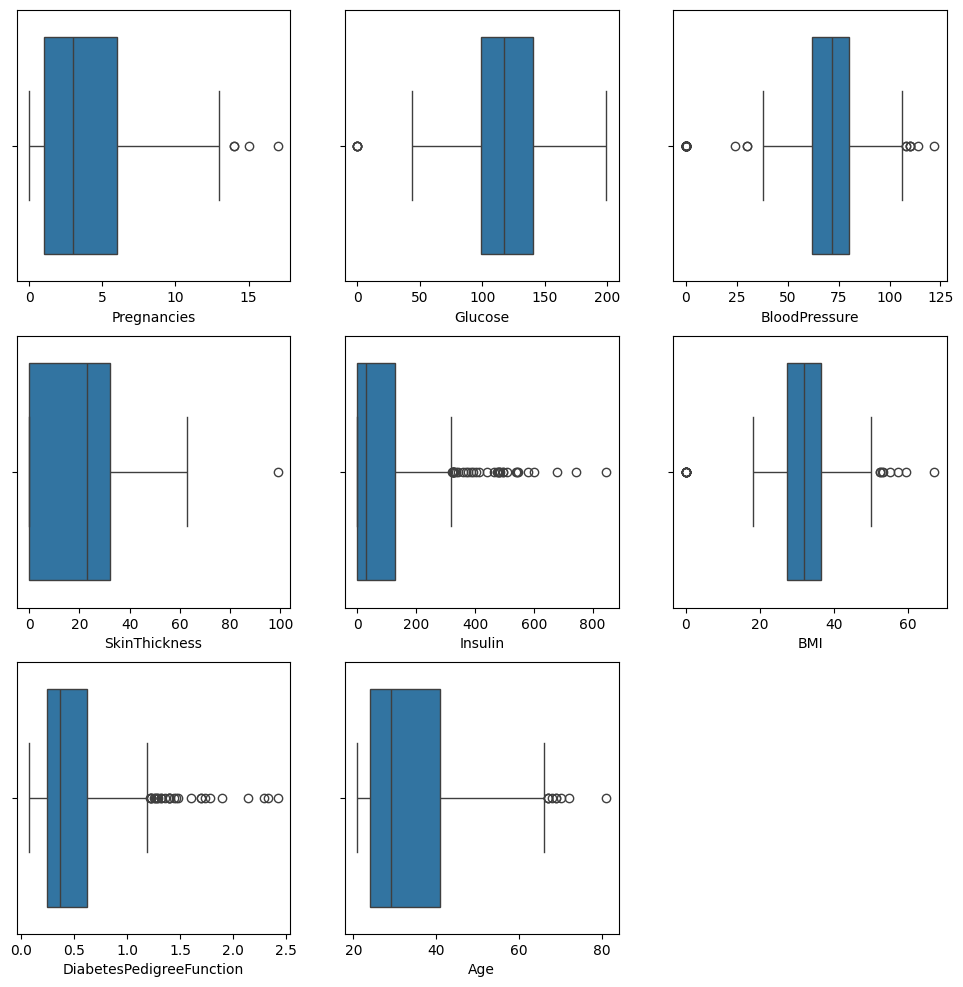

In [ ]:
plt.figure(figsize= (12,12))
for i, col in enumerate(['Pregnancies', 'Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']):
    plt.subplot(3,3, i+1)
    sns.boxplot(x = col, data = df1)
plt.show()

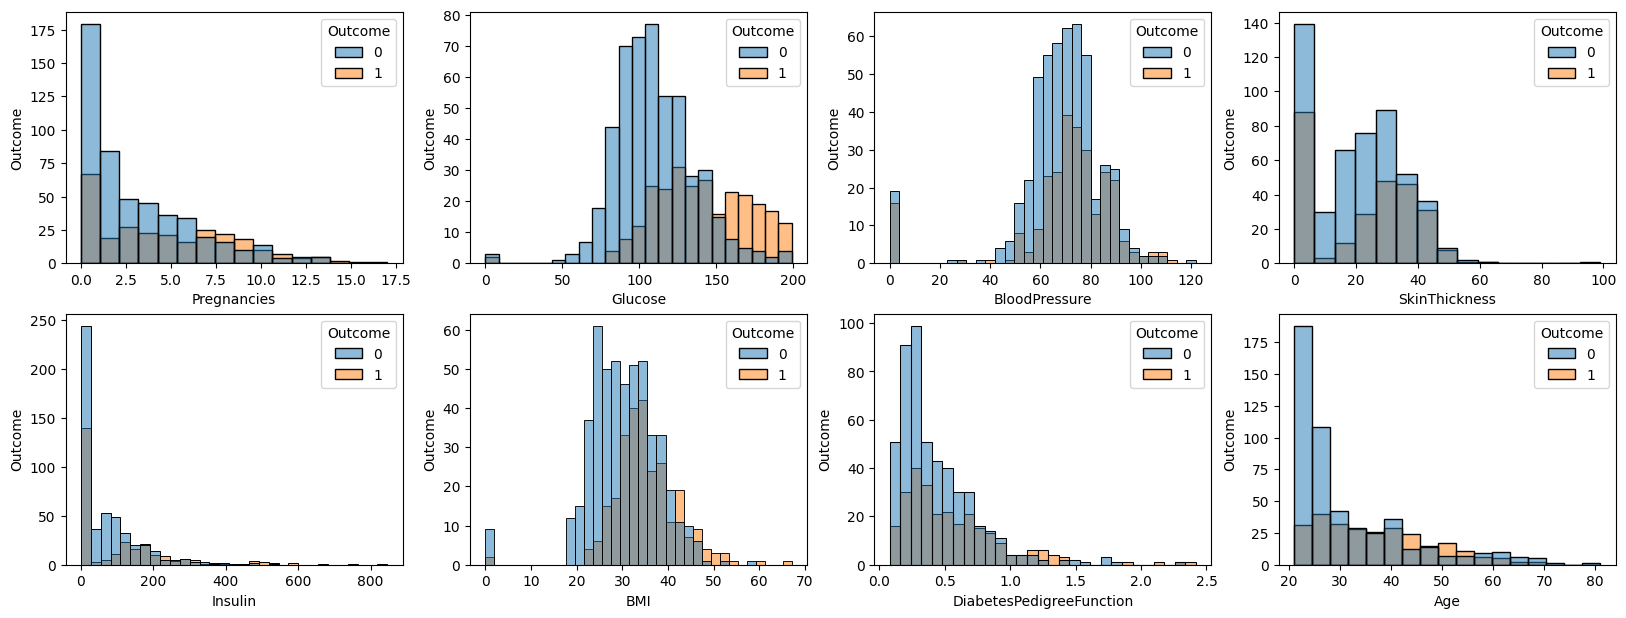

In [ ]:
plotnumber=1
featureList=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
plt.figure(figsize=(20,15),facecolor='white')
for i in featureList:
    if(plotnumber<=8):
        plt.subplot(4,4,plotnumber)
        sns.histplot(x=i,data=df1,hue='Outcome')
        plt.xlabel(i)
        plt.ylabel('Outcome')
        plotnumber+=1

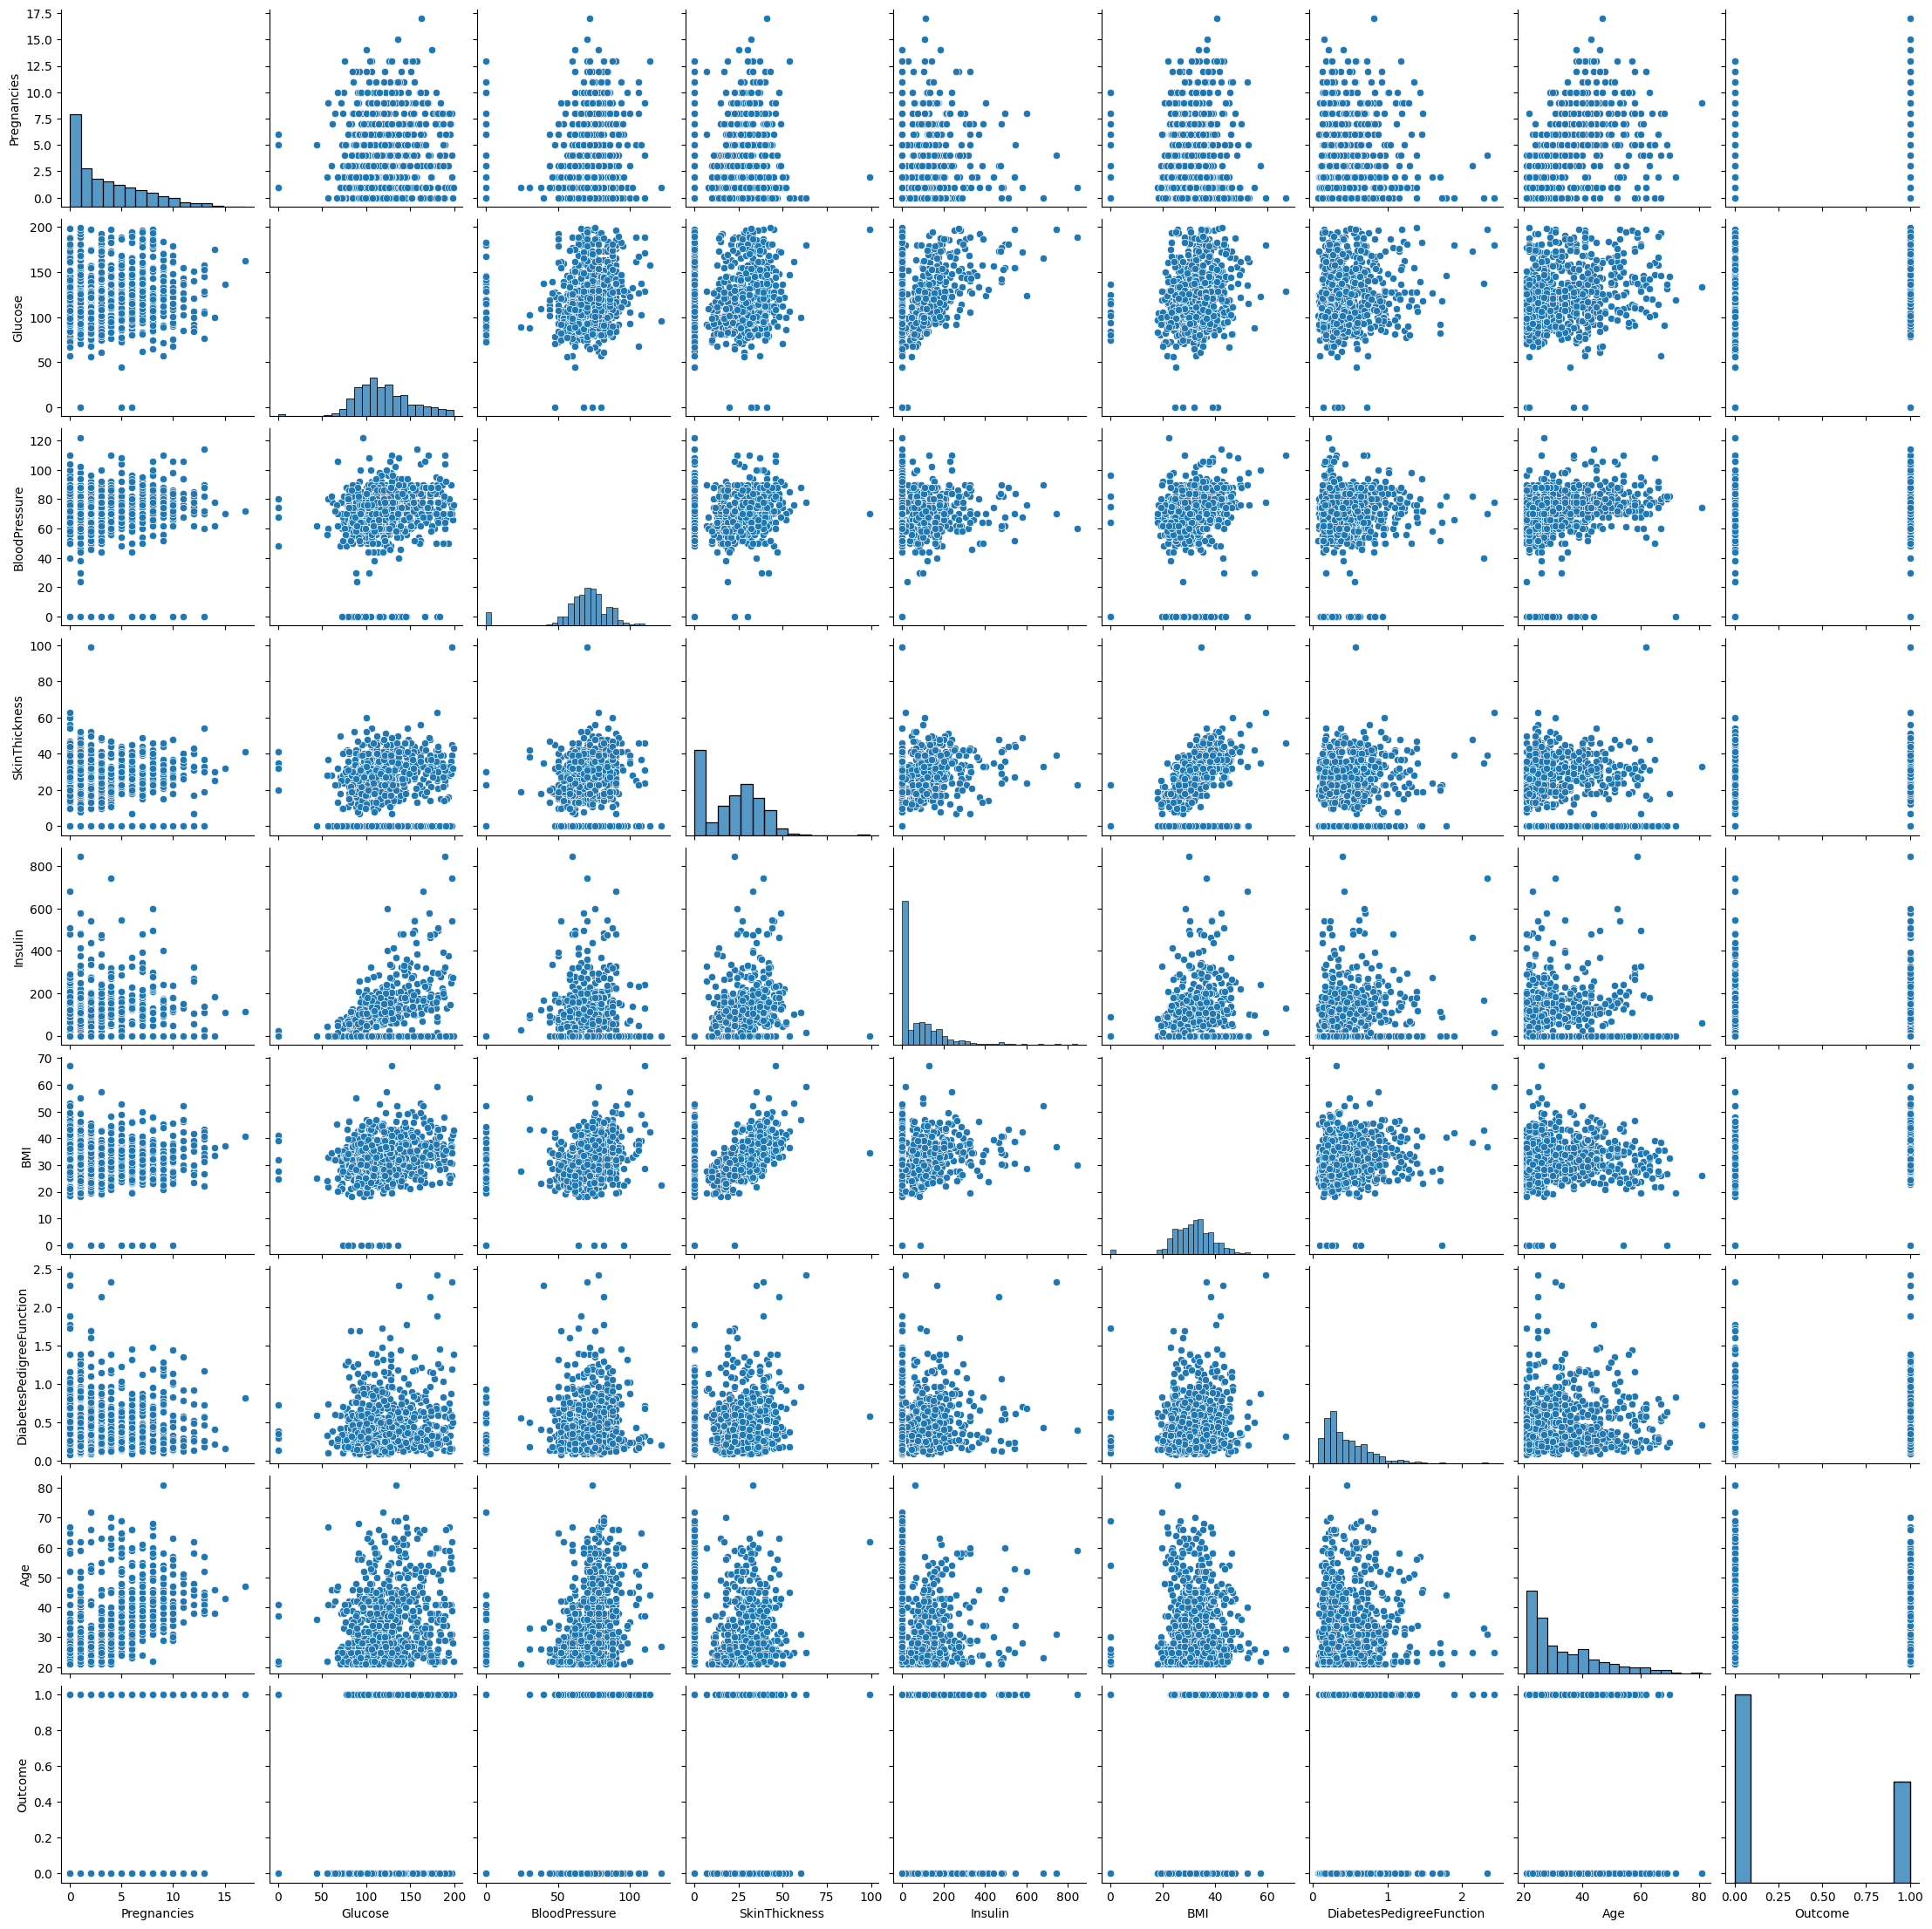

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.pairplot(df1)


In [ ]:
#Dataset=[X_train,X_test]
#for data in Dataset:
   # pass  # Add a placeholder action if you need to iterate but don't have specific code yet

In [ ]:
df1.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


Change Dibetc & NonDiabetic

In [ ]:


df1['Target'] = df1['Outcome']

# Display the first few rows to verify
print(df1.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  Target  
0                     0.627   50        1       1  
1                     0.351   31        0       0  
2                     0.672   32        1       1  
3                     0.167   21        0       0  
4                     2.288   33        1       1  


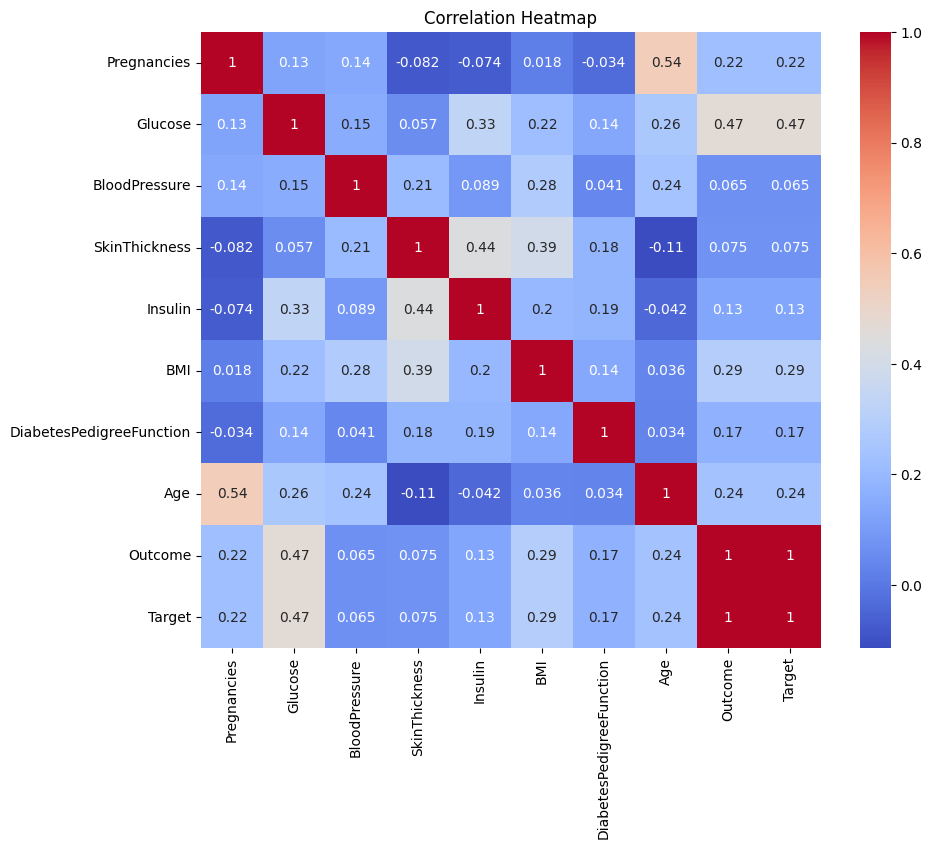

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
corr = df1.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:

df1.loc[df1["Outcome"] == 1, "Outcome"] = " Diabetic"
df1.loc[df1["Outcome"] == 0, "Outcome"] = "Nondiabetc"

<ipython-input-14-8d185d66b8b4>:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value ' Diabetic' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df1.loc[df1["Outcome"] == 1, "Outcome"] = " Diabetic"


In [ ]:
df1.head(40)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Target
0,6,148,72,35,0,33.6,0.627,50,Diabetic,1
1,1,85,66,29,0,26.6,0.351,31,Nondiabetc,0
2,8,183,64,0,0,23.3,0.672,32,Diabetic,1
3,1,89,66,23,94,28.1,0.167,21,Nondiabetc,0
4,0,137,40,35,168,43.1,2.288,33,Diabetic,1
5,5,116,74,0,0,25.6,0.201,30,Nondiabetc,0
6,3,78,50,32,88,31.0,0.248,26,Diabetic,1
7,10,115,0,0,0,35.3,0.134,29,Nondiabetc,0
8,2,197,70,45,543,30.5,0.158,53,Diabetic,1
9,8,125,96,0,0,0.0,0.232,54,Diabetic,1


In [ ]:

df1.isnull().sum()
df1

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Target
0,6,148,72,35,0,33.6,0.627,50,Diabetic,1
1,1,85,66,29,0,26.6,0.351,31,Nondiabetc,0
2,8,183,64,0,0,23.3,0.672,32,Diabetic,1
3,1,89,66,23,94,28.1,0.167,21,Nondiabetc,0
4,0,137,40,35,168,43.1,2.288,33,Diabetic,1
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,Nondiabetc,0
764,2,122,70,27,0,36.8,0.340,27,Nondiabetc,0
765,5,121,72,23,112,26.2,0.245,30,Nondiabetc,0
766,1,126,60,0,0,30.1,0.349,47,Diabetic,1


In [ ]:
#new_column_data = [0] * len(df1)
#df1["Diabetic & NonDibetic"] = new_column_data

In [ ]:
# separating the data and labels
X =df1.drop(columns = 'Outcome', axis=1)
Y = df1['Outcome']

In [ ]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Target  
0                       0.627   50       1  
1                    

In [ ]:


print(Y)

0        Diabetic
1      Nondiabetc
2        Diabetic
3      Nondiabetc
4        Diabetic
          ...    
763    Nondiabetc
764    Nondiabetc
765    Nondiabetc
766      Diabetic
767    Nondiabetc
Name: Outcome, Length: 768, dtype: object


Data Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  # Now StandardScaler should be recognized

In [ ]:
scaler = StandardScaler()

In [ ]:
scaler.fit(X)

StandardScaler()

In [ ]:


standardized_data = scaler.transform(X)

In [ ]:

print(standardized_data)

[[ 0.63994726  0.84832379  0.14964075 ...  0.46849198  1.4259954
   1.36589591]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.36506078 -0.19067191
  -0.73212021]
 [ 1.23388019  1.94372388 -0.26394125 ...  0.60439732 -0.10558415
   1.36589591]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.68519336 -0.27575966
  -0.73212021]
 [-0.84488505  0.1597866  -0.47073225 ... -0.37110101  1.17073215
   1.36589591]
 [-0.84488505 -0.8730192   0.04624525 ... -0.47378505 -0.87137393
  -0.73212021]]


In [ ]:
X = standardized_data
Y = df1['Outcome']

In [ ]:
print(X)
print(Y)

[[ 0.63994726  0.84832379  0.14964075 ...  0.46849198  1.4259954
   1.36589591]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.36506078 -0.19067191
  -0.73212021]
 [ 1.23388019  1.94372388 -0.26394125 ...  0.60439732 -0.10558415
   1.36589591]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.68519336 -0.27575966
  -0.73212021]
 [-0.84488505  0.1597866  -0.47073225 ... -0.37110101  1.17073215
   1.36589591]
 [-0.84488505 -0.8730192   0.04624525 ... -0.47378505 -0.87137393
  -0.73212021]]
0        Diabetic
1      Nondiabetc
2        Diabetic
3      Nondiabetc
4        Diabetic
          ...    
763    Nondiabetc
764    Nondiabetc
765    Nondiabetc
766      Diabetic
767    Nondiabetc
Name: Outcome, Length: 768, dtype: object


Train Test Split

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, stratify=Y, random_state=2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(768, 9) (614, 9) (154, 9)


Training the Model

In [ ]:


from sklearn.svm import SVC

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, stratify=Y, random_state=2)
print(X.shape, X_train.shape, X_test.shape)

# Initialize the SVM classifier
classifier = SVC(kernel='linear')

(768, 9) (614, 9) (154, 9)


In [ ]:
#training the support vector Machine Classifier
classifier.fit(X_train, Y_train)

SVC(kernel='linear')

Model Evaluation

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
test_scores =[]
train_scores = []

for i in range(1,15):
    knn = KNeighborsClassifier(i)
    knn.fit(X_train, Y_train)

    train_scores.append(knn.score(X_train, Y_train))
    test_scores.append(knn.score(X_test, Y_test))


Accuracy Score

In [ ]:

# Import the necessary function
from sklearn.metrics import accuracy_score

# accuracy score on the training data
X_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [ ]:
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  1.0


In [ ]:

# accuracy score on the test data
X_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [ ]:
print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  1.0


Making a Predictive System

In [ ]:

input_data = (1,85,66,29,0,26.6,0.37,31,0)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardize the input data
std_data = scaler.transform(input_data_reshaped)
print(std_data)

prediction = classifier.predict(std_data)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[[-0.84488505 -1.12339636 -0.16054575  0.53090156 -0.69289057 -0.68442195
  -0.30767852 -0.19067191 -0.73212021]]
['Nondiabetc']
The person is diabetic


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
input_data = (5,166,72,19,175,25.8,0.587,51,1)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)


# standardize the input data
std_data = scaler.transform(input_data_reshaped)
print(std_data)

prediction = classifier.predict(std_data)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[[ 0.3429808   1.41167241  0.14964075 -0.09637905  0.82661621 -0.78595734
   0.34768723  1.51108316  1.36589591]]
[' Diabetic']
The person is diabetic


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


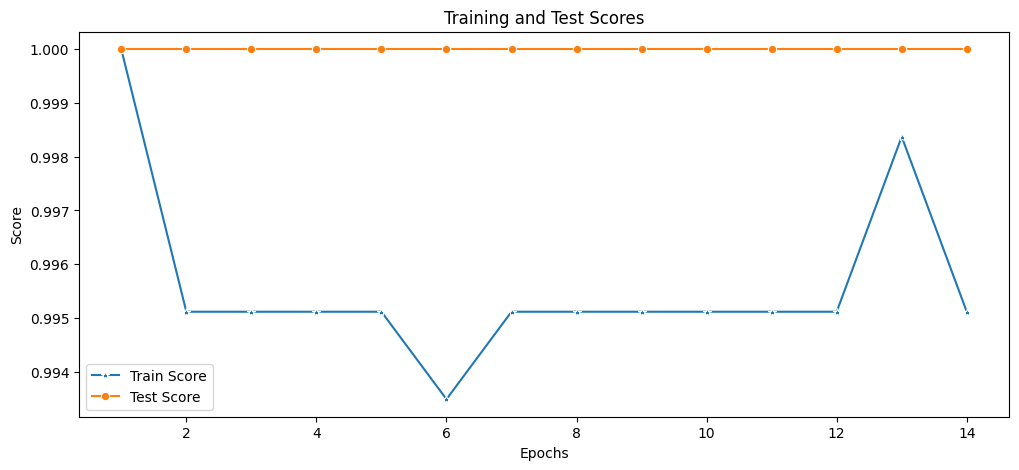

In [ ]:
plt.figure(figsize=(12, 5))
p = sns.lineplot(x=list(range(1, 15)), y=train_scores, marker='*', label='Train Score')
p = sns.lineplot(x=list(range(1, 15)), y=test_scores, marker='o', label='Test Score')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.title('Training and Test Scores')
plt.legend()
plt.show()

<Axes: xlabel='Pregnancies'>

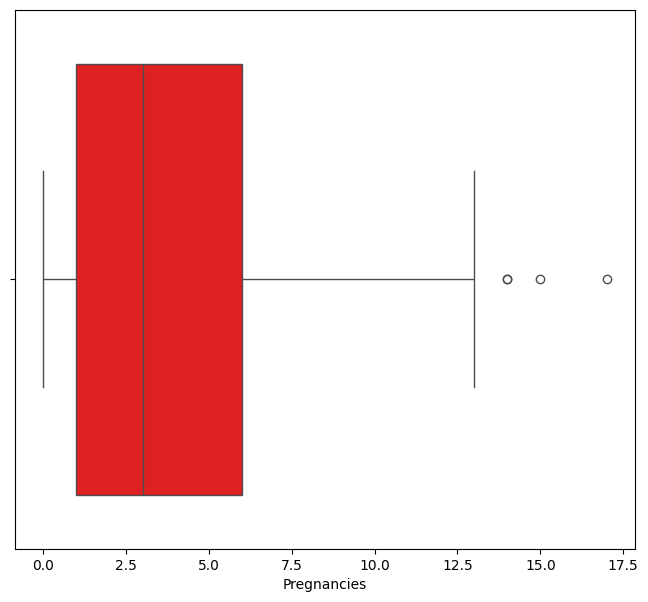

In [ ]:
plt.figure(figsize=(8,7))
sns.boxplot(x= df1["Pregnancies"], color="red")


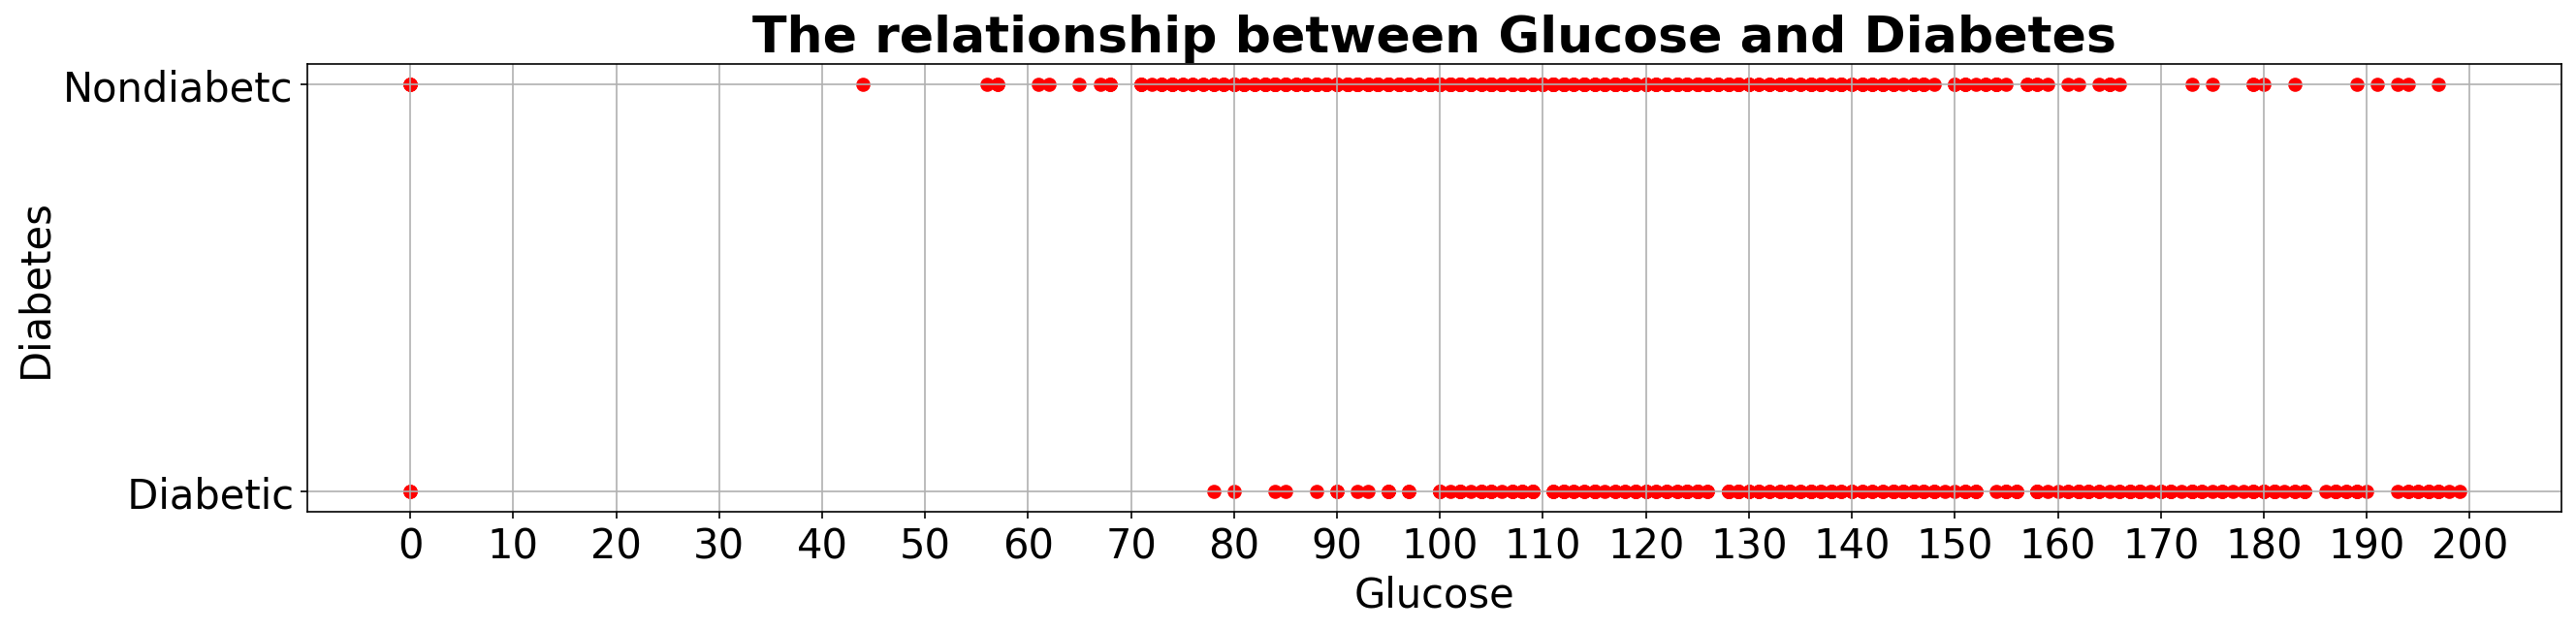

In [ ]:
plt.figure(figsize = [20, 4] , dpi = 150)
plt.scatter (df1["Glucose"] , df1["Outcome"] , color = "red")
plt.title ("The relationship between Glucose and Diabetes" , weight='bold', fontsize = 25)
plt.xticks (range (0 , 205 , 10), fontsize = 20)
plt.yticks (fontsize = 20)
plt.xlabel ('Glucose', fontsize = 20 )
plt.ylabel ('Diabetes' , fontsize = 20)
plt.grid ()
plt.show ()

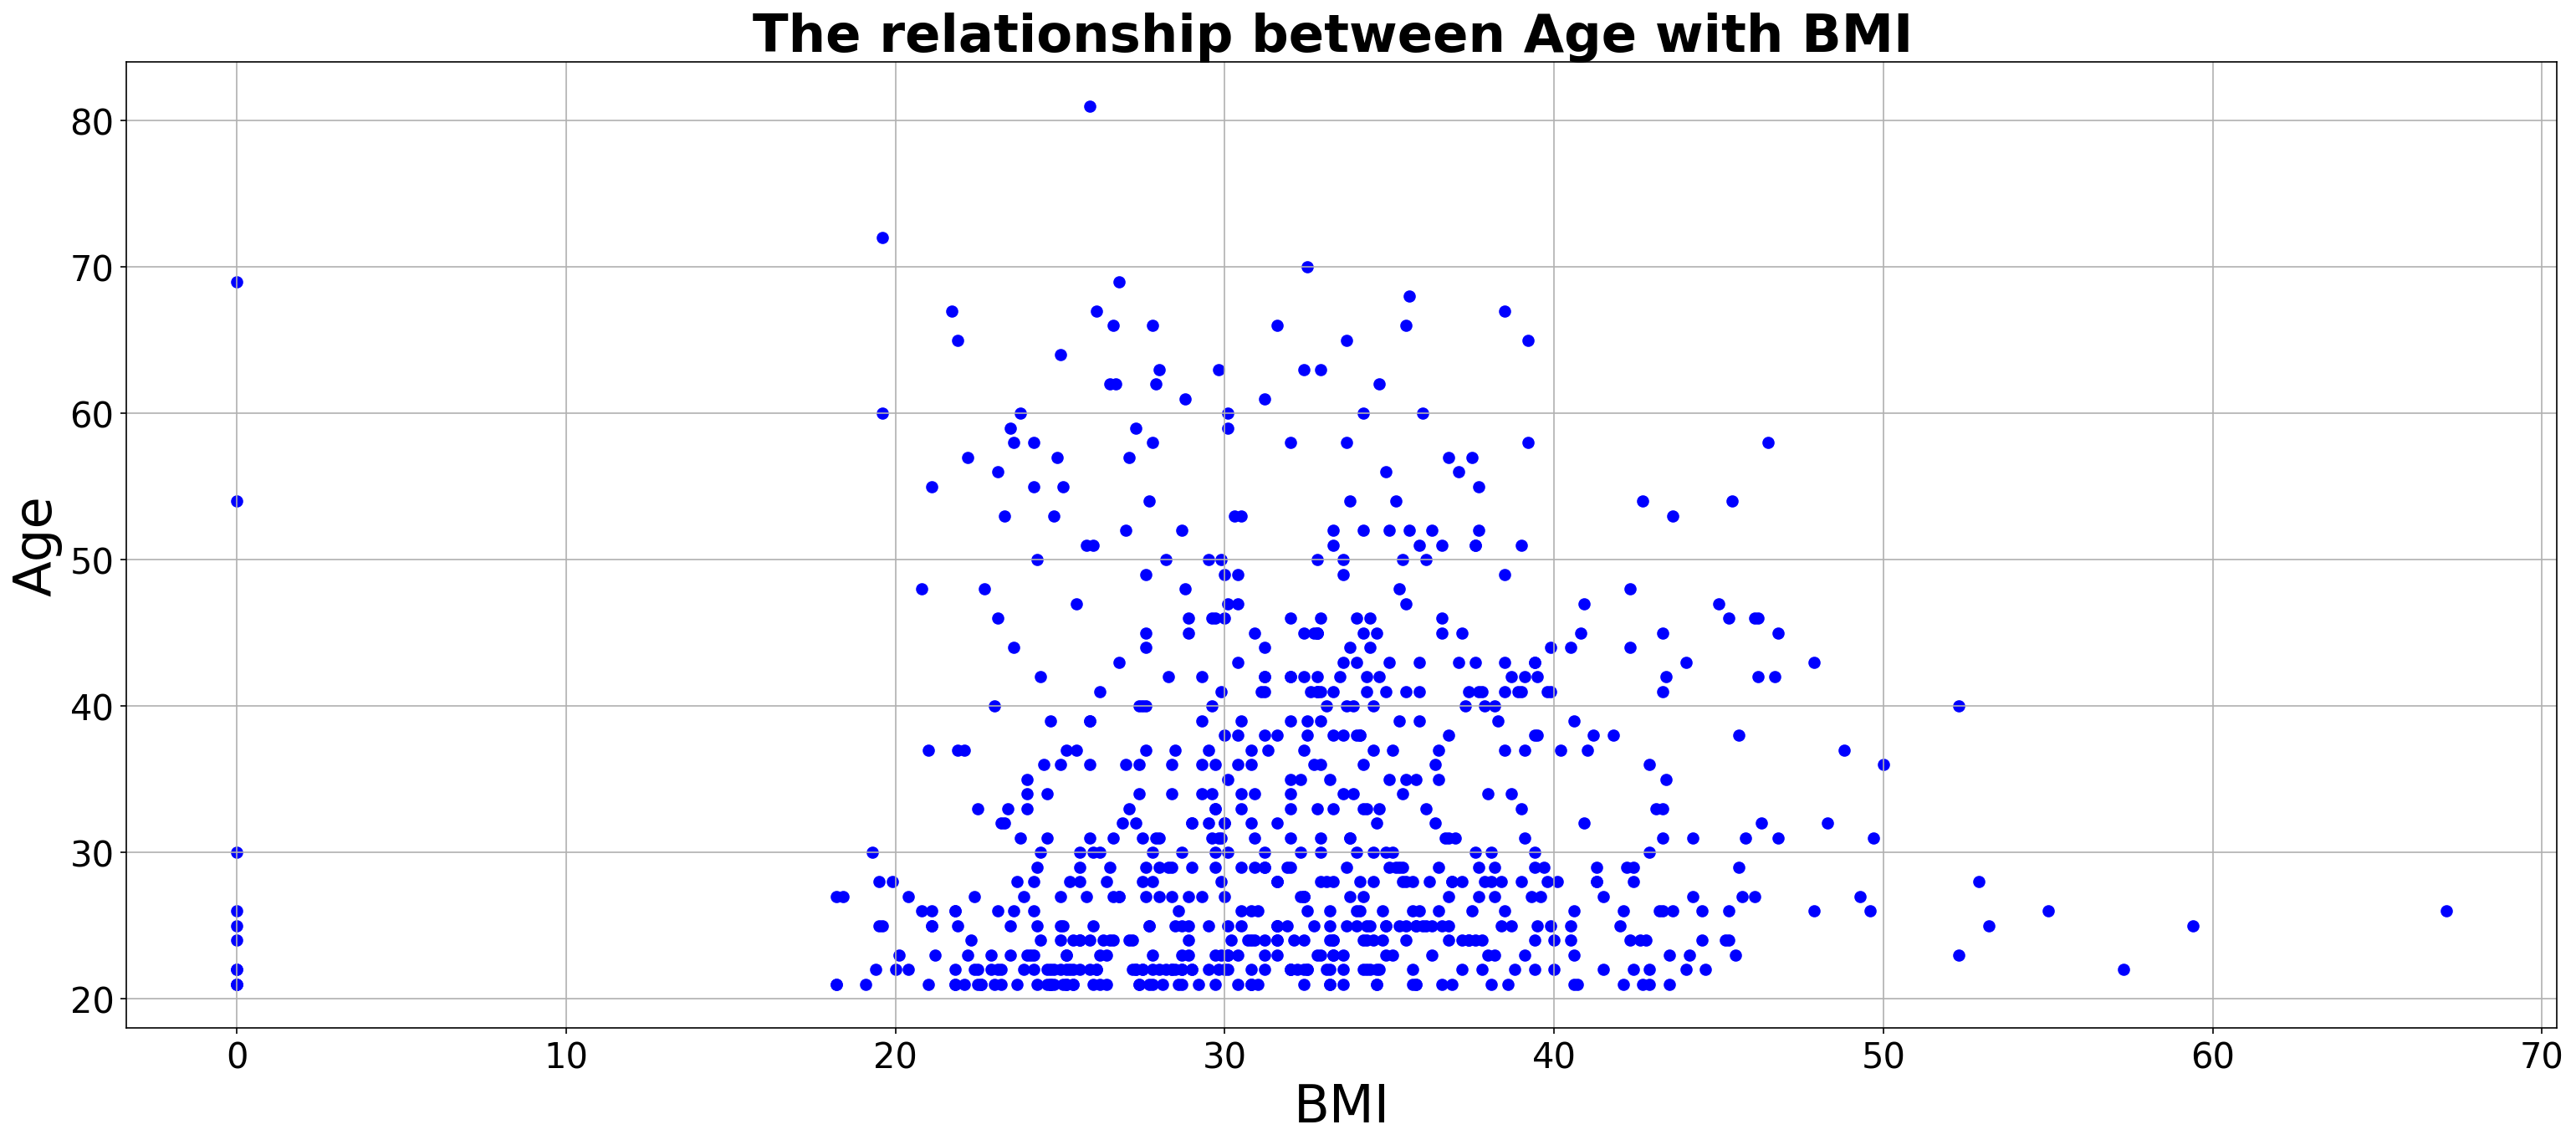

In [ ]:
plt.figure(figsize = [25, 10] , dpi = 150)
plt.scatter (df1["BMI"] , df1["Age"] , color = "blue")
plt.title ("The relationship between Age with BMI " , weight = 'bold', fontsize = 30)
plt.xticks (range (0 , 80 , 10) , fontsize = 20)
plt.yticks (range (20 , 90 , 10) , fontsize = 20)
plt.xlabel ('BMI', fontsize = 30 )
plt.ylabel ('Age' , fontsize = 30)
plt.grid ()
plt.show ()

(array([268.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 500.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

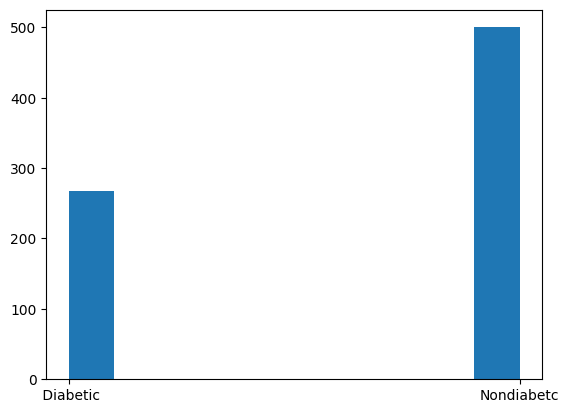

In [ ]:
plt.hist(Y)

In [ ]:
log=LogisticRegression (solver = "liblinear")

log.fit(X_train ,Y_train)                     # Fitting a  model
y_pred =log.predict(X_test)                    # Predicted class labels from test features
y_predicted_proba=log.predict_proba(X_test)   # Predicted probabilities from test features

In [ ]:
print ("Accuracy: ",metrics.accuracy_score (Y_test ,y_pred))

Accuracy:  1.0


In [ ]:

log.intercept_


array([1.48729861])

In [ ]:
log.coef_


array([[-0.15204173, -0.37659925,  0.0859842 , -0.03937564,  0.03721488,
        -0.2045699 , -0.08362119, -0.08193924, -4.46288775]])

In [ ]:
log.predict(X)

array([' Diabetic', 'Nondiabetc', ' Diabetic', 'Nondiabetc', ' Diabetic',
       'Nondiabetc', ' Diabetic', 'Nondiabetc', ' Diabetic', ' Diabetic',
       'Nondiabetc', ' Diabetic', 'Nondiabetc', ' Diabetic', ' Diabetic',
       ' Diabetic', ' Diabetic', ' Diabetic', 'Nondiabetc', ' Diabetic',
       'Nondiabetc', 'Nondiabetc', ' Diabetic', ' Diabetic', ' Diabetic',
       ' Diabetic', ' Diabetic', 'Nondiabetc', 'Nondiabetc', 'Nondiabetc',
       'Nondiabetc', ' Diabetic', 'Nondiabetc', 'Nondiabetc',
       'Nondiabetc', 'Nondiabetc', 'Nondiabetc', ' Diabetic', ' Diabetic',
       ' Diabetic', 'Nondiabetc', 'Nondiabetc', 'Nondiabetc', ' Diabetic',
       'Nondiabetc', ' Diabetic', 'Nondiabetc', 'Nondiabetc', ' Diabetic',
       'Nondiabetc', 'Nondiabetc', 'Nondiabetc', 'Nondiabetc',
       ' Diabetic', 'Nondiabetc', 'Nondiabetc', ' Diabetic', 'Nondiabetc',
       'Nondiabetc', 'Nondiabetc', 'Nondiabetc', ' Diabetic',
       'Nondiabetc', 'Nondiabetc', ' Diabetic', 'Nondiabetc', ' Diabe

In [ ]:
confusion_matrix (Y,log.predict (X))

array([[268,   0],
       [  0, 500]])

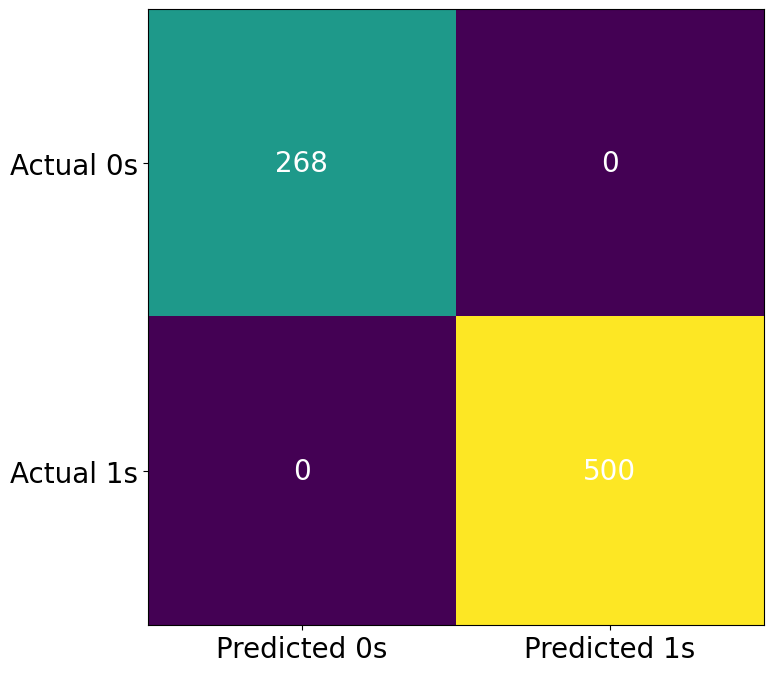

In [ ]:

cm = confusion_matrix (Y , log.predict(X))

fig , ax = plt.subplots (figsize = (8,8))
ax.imshow (cm)
ax.grid (False)
ax.xaxis.set (ticks = (0 , 1) , ticklabels = ("Predicted 0s" , "Predicted 1s"))
ax.yaxis.set (ticks = (0 , 1) , ticklabels = ("Actual 0s" , "Actual 1s"))

ax.tick_params(axis='both', which='major', labelsize=20)
#ax.tick_params(axis='both', which='minor', labelsize=20)
#plt.xticks(fontsize=14, rotation=90)

ax.set_ylim (1.5 , -0.5)
for i in range (2):
    for j in range (2):
        ax.text (j , i , cm[i,j] , ha = "center" , va ="center" , color ="white", fontsize = 20 )

In [ ]:

print (classification_report (Y , log.predict (X)))

              precision    recall  f1-score   support

    Diabetic       1.00      1.00      1.00       268
  Nondiabetc       1.00      1.00      1.00       500

    accuracy                           1.00       768
   macro avg       1.00      1.00      1.00       768
weighted avg       1.00      1.00      1.00       768



#Create RNN Model In Diabetic Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

df1=pd.read_csv("/content/diabetes.csv")
df1

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df1.shape

(768, 9)

In [ ]:
df1.size

6912

In [ ]:



df1.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:

X=df1.iloc[:,:-1].values
Y=df1.iloc[:,-1].values

In [ ]:
X.shape

(768, 8)

In [ ]:
Y.shape

(768,)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

In [ ]:
# Split the data
x_train, x_test, y_train, y_test = train_test_split(X_reshaped, Y, test_size=0.2, random_state=42)

In [ ]:
x_train.shape

(614, 8, 1)

In [ ]:

y_train.shape

(614,)

In [ ]:
y_test.shape

(154,)

In [ ]:

x_test.shape

(154, 8, 1)

In [ ]:

from keras.models import Sequential
from keras.utils import to_categorical
import tensorflow as tf
from tensorflow import keras
#from keras.layers import LSTM
from keras.layers import Dense
from keras.optimizers import Adam

In [ ]:
# Build a binary classification model
model = Sequential([
    Dense(64, input_dim=x_train.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Sigmoid activation for binary classification
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
model.fit(x_train, y_train, epochs=10, batch_size=32, verbose=1)


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6674 - loss: 0.6624
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7467 - loss: 0.5796
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7853 - loss: 0.5252
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7955 - loss: 0.4739
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7671 - loss: 0.4717
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7880 - loss: 0.4597
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7905 - loss: 0.4505
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7839 - loss: 0.4506
Epoch 9/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7832 - loss: 0.4288
Epoch 10/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7898 - loss: 0.4456


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,069 (31.52 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,380 (21.02 KB)

In [ ]:
x_test[:10]

array([[[ 0.63994726],
        [-0.71653347],
        [-0.57412775],
        [ 0.7818138 ],
        [ 0.95685965],
        [ 0.25478047],
        [-0.1264714 ],
        [ 0.83038113]],

       [[-0.54791859],
        [-0.27837344],
        [ 0.304734  ],
        [ 0.71908574],
        [-0.69289057],
        [ 0.47054319],
        [-0.97814487],
        [-1.04154944]],

       [[-0.54791859],
        [-0.40356202],
        [-0.26394125],
        [-1.28821221],
        [-0.69289057],
        [-0.15136112],
        [-0.94794368],
        [-1.04154944]],

       [[ 1.23388019],
        [-0.43485916],
        [ 0.56322275],
        [-1.28821221],
        [-0.69289057],
        [-0.93826044],
        [ 1.16009915],
        [ 0.06459135]],

       [[ 0.93691372],
        [ 0.47275805],
        [ 1.08020025],
        [-1.28821221],
        [-0.69289057],
        [-0.26558844],
        [-0.79089751],
        [ 1.4259954 ]],

       [[ 0.63994726],
        [-0.56004775],
        [ 0.14964075],
 

In [ ]:
predictions = model.predict(x_test[:10])
binary_predictions = (predictions > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [ ]:
predictions = model.predict(x_test[:10])

This generates predicted values (likely probabilities if your model has a sigmoid activation in the final layer) for the first 10 test samples.
binary_predictions = (predictions > 0.5).astype(int)

This converts the probabilities into binary values (0 or 1). If a prediction is greater than 0.5, it is classified as 1 (diabetic), otherwise 0 (non-diabetic).

In [ ]:
for i, pred in enumerate(binary_predictions):
    print(f"Sample {i+1}: Predicted: {'Diabetic' if pred[0] == 1 else 'Non-Diabetic'}, Probability: {predictions[i][0]:.2f}")


Sample 1: Predicted: Non-Diabetic, Probability: 0.45
Sample 2: Predicted: Non-Diabetic, Probability: 0.07
Sample 3: Predicted: Non-Diabetic, Probability: 0.09
Sample 4: Predicted: Non-Diabetic, Probability: 0.21
Sample 5: Predicted: Non-Diabetic, Probability: 0.41
Sample 6: Predicted: Diabetic, Probability: 0.61
Sample 7: Predicted: Non-Diabetic, Probability: 0.01
Sample 8: Predicted: Diabetic, Probability: 0.59
Sample 9: Predicted: Diabetic, Probability: 0.68
Sample 10: Predicted: Diabetic, Probability: 0.69


In [ ]:
f"Sample {i+1}" → Displays sample number (starting from 1 instead of 0).
'Diabetic' if pred[0] == 1 else 'Non-Diabetic'
If the predicted outcome (pred[0]) is 1, it prints "Diabetic".
Otherwise, it prints "Non-Diabetic".
predictions[i][0]:.2f
This extracts the raw probability score from predictions[i][0] and rounds it to 2 decimal places for readability.

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7155 - loss: 0.5241  
Test Loss: 0.5181924104690552, Test Accuracy: 0.7402597665786743


#cnn model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, BatchNormalization, MaxPooling1D
from tensorflow.keras.optimizers import Adam

In [ ]:
model = Sequential([
    Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(X.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Conv1D(filters=64, kernel_size=2, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=16)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5040 - loss: 0.9143 - val_accuracy: 0.6429 - val_loss: 0.6684
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6006 - loss: 0.7642 - val_accuracy: 0.6494 - val_loss: 0.6742
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5828 - loss: 0.7347 - val_accuracy: 0.6234 - val_loss: 0.6703
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6129 - loss: 0.7152 - val_accuracy: 0.6234 - val_loss: 0.6667
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5844 - loss: 0.7095 - val_accuracy: 0.6299 - val_loss: 0.6608
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5861 - loss: 0.7250 - val_accuracy: 0.6429 - val_loss: 0.6546
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6356 - loss: 0.6941 - val_accuracy: 0.6039 - val_loss: 0.6562
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6618 - loss: 0.6683 - val_accuracy: 0.6169 - val_loss

In [ ]:
#Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6488 - loss: 0.6658 
Test Accuracy: 62.99%


In [ ]:

# Function to predict diabetes status
def predict_diabetes(input_data):
    input_array = np.array(input_data).reshape(1, -1, 1)
    input_array = scaler.transform(input_array.reshape(1, -1)).reshape(1, -1, 1)
    prediction = model.predict(input_array)
    return "Diabetic" if prediction >= 0.5 else "Non-Diabetic"


In [ ]:

# Example usage
user_input = [6,	148,	72,	35,	0,	33.6,	0.627,	50]  # Replace with actual input
print("Prediction:", predict_diabetes(user_input))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
Prediction: Non-Diabetic


In [ ]:
user_input = [1,	85,	66,	29,	0,	26.6,	0.351,	31	]  # Replace with actual input
print("Prediction:", predict_diabetes(user_input))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Prediction: Non-Diabetic


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_true,y_predict)
plt.show()

NameError: name 'y_true' is not defined